In [1]:
import scipy.stats

"""
Galaxy Morphology Analysis: Ellipticity-Surface Brightness Correlation
====================================================================
This code analyzes the correlation between galaxy ellipticity and surface brightness
following Xu & Randall 2020.
"""

import os
import sys
import warnings
import numpy as np
import time
from typing import Optional, Dict
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import traceback
import pickle
import galaxy_ellipse_collection as gec
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import time
from typing import Optional, Dict, List
from collections import defaultdict
TIMING_DATA = defaultdict(list)
ENABLE_TIMING = True

import logging


logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

warnings.filterwarnings("ignore")

# ===========================
# Configuration and Setup
# ===========================

import sys
from config import db_connection, sys_path, xu_output_dir
os.environ['TANGOS_DB_CONNECTION'] = db_connection
os.environ['TANGOS_PROPERTY_MODULES'] = 'mytangosproperty'
sys.path.append(sys_path)
import tangos

import mytangosproperty
from galaxy_ellipse_collection import random_viewing_angles, interpolate_orientations

import Load_Galaxies_Xu as lgx

# Physical constants
MASS_TO_LIGHT_THRESHOLD = 85  # M_sun/L_sun threshold for bright/dim classification

# Output directory
OUTPUT_DIR = xu_output_dir
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)




# ===========================
# Plotting Functions
# ===========================


"""
Galaxy Morphology Analysis: Ellipticity-Surface Brightness Correlation
====================================================================
This code analyzes the correlation between galaxy ellipticity and surface brightness
following Xu & Randall 2020. It processes simulation data and compares with observations
of Local Group dwarf spheroidal galaxies.
"""

import os
import sys
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import traceback
import pickle
import galaxy_ellipse_collection as gec
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import time
from typing import Optional, Dict, List
from collections import defaultdict
TIMING_DATA = defaultdict(list)
ENABLE_TIMING = True

warnings.filterwarnings("ignore")

# ===========================
# Configuration and Setup
# ===========================

import sys
from config import db_connection, sys_path, xu_output_dir
os.environ['TANGOS_DB_CONNECTION'] = db_connection
os.environ['TANGOS_PROPERTY_MODULES'] = 'mytangosproperty'
sys.path.append(sys_path)
import tangos

import mytangosproperty
from galaxy_ellipse_collection import random_viewing_angles, interpolate_orientations, spherical_to_rotation_angles

# Physical constants
MASS_TO_LIGHT_THRESHOLD = 85  # M_sun/L_sun threshold for bright/dim classification

# Analysis parameters
N_ITERATIONS = 1000  # Number of Monte Carlo iterations
MIN_STAR_PARTICLES = 10000  # Minimum star particles for analysis

# Output directory
OUTPUT_DIR = xu_output_dir
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)


# ===========================
# Analysis Functions
# ===========================



0.11949915052155573 6.182438928049719
0.05044185665931592 3.081361619568153
0.09169029997100686 6.242274551360859
0.1046408240679165 3.03115570020129
0.13178297294846728 6.246193573849446
0.1847587545854546 2.984532796557604
0.06036345358895704 6.231688286590951
0.16638699956394729 2.9772278530575975
0.0027583406906322434 6.238334580987334
0.3384684810731968 2.7147900499215494
0.006220360748868551 6.12707644276222
0.23787199434910564 3.0824588411838705
0.06303522131258904 6.219560840860997
0.18291002890075025 3.048233416954047
0.018433051708086595 6.278750112051382
0.2281974322984323 2.695620314784862
0.13185072165743236 6.215827257807506
0.08326659969205165 3.044232883526713
0.06679039510314057 6.253966670704048
0.1095887483552677 3.04687779571708
0.11962655845917554 6.261301567407408
0.15673619160341432 2.934110810349195
0.013683921871955116 6.232149526163355
0.26095528163770954 2.9783115514227125
0.11374750570251965 6.2473903389129495
0.10619550376386719 3.020210050261606
0.10725823

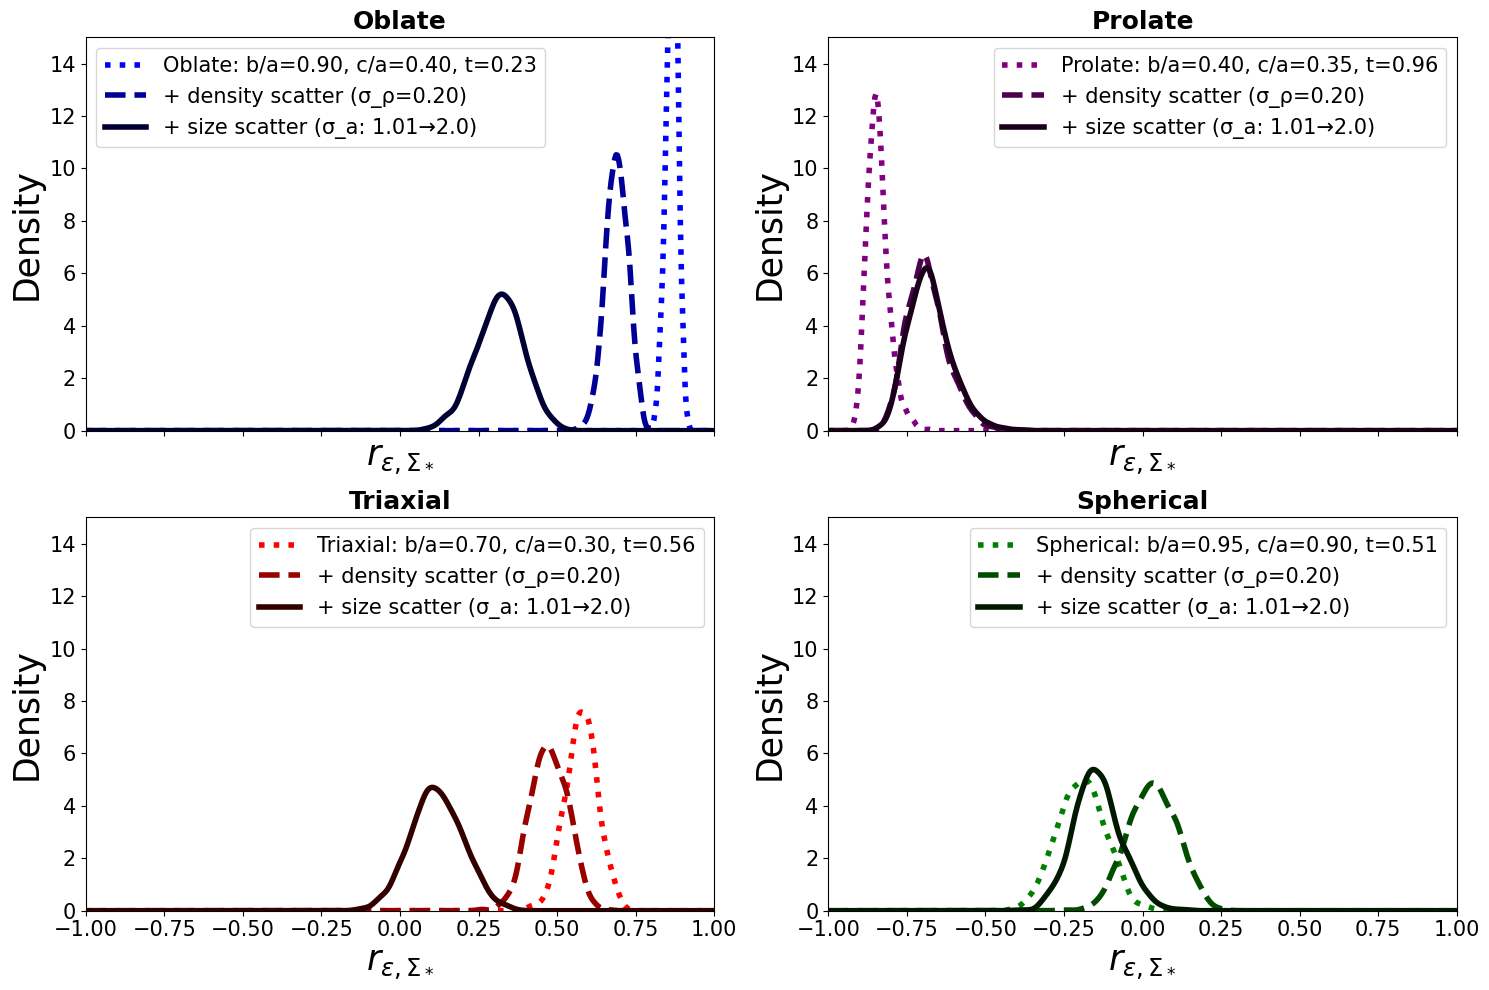

In [2]:
def calculate_central_sb_and_ellipticty(theta,phi,rho_0,a,b,c):
    alpha = (a*np.cos(theta)*np.cos(phi))**2 + (b*np.cos(theta)*np.sin(phi))**2 + (c*np.sin(theta))**2
    beta = (a*np.sin(phi))**2 + (b*np.cos(phi))**2
    gamma = (a**2 - b**2)*np.cos(theta)*np.sin(phi)*np.cos(phi)
    f = np.sqrt(4*gamma**2 + (alpha - beta)**2)
    ell = 1 - np.sqrt( 1 - (2*f)/(alpha+beta+f))
    sb_0 = 4/3* rho_0 * (a*b*c)/(np.sqrt(alpha*beta-gamma**2))
    return ell, sb_0


#from shape_inference import generate_ellipsoid_distribution, random_viewing_angles
import shape_inference as si
import scipy
import matplotlib.colors as mcolors

# Helper function to darken colors progressively
def darken_color(color, amount=0.4):
    """
    Darkens a matplotlib color by mixing it with black.
    amount: 0 = original color, 1 = black
    """
    try:
        c = mcolors.to_rgb(color)
    except ValueError:
        c = mcolors.to_rgb(mcolors.CSS4_COLORS.get(color, 'black'))

    # Mix with black to darken
    return tuple(max(0, channel * (1 - amount)) for channel in c)


# 4 tests, oblate, prolate, triaxial, spherical
tests = {
    'oblate':    {'a':1, 'b':.9, 'c':0.4, 'color': 'b'},
    'prolate':   {'a':1, 'b':0.4, 'c':0.35, 'color': 'purple'},
    'triaxial':  {'a':1, 'b':0.7, 'c':0.3, 'color': 'red'},
    'spherical': {'a':1, 'b':0.95, 'c':0.9, 'color': 'g'}
}

n_iterations = 2000
n_samples = 100
err = 0.05
rho_d = [0.01, 0.2]
a = [1.01, 2]
linestyles = ['-', '--', ':']

np.random.seed(4)


def plot_model_correlation(n_samples, ba, ca, err, rho_d, a_d, ax, c, linestyle, label):
    corr_dist = np.zeros(n_iterations) * np.nan
    rho_0 = np.random.normal(1, rho_d, size=n_samples)
    a_vals = np.random.uniform(1, a_d, size=n_samples)
    B_samples, C_samples = si.generate_ellipsoid_distribution(n_samples, ba, err, ca, err)

    for i in range(n_iterations):
        phi,theta = si.random_viewing_angles(n_samples)
        print(np.min(phi), np.max(phi))
        print(np.min(theta), np.max(theta))
        ell, sb_0 = calculate_central_sb_and_ellipticty(theta, phi, rho_0, a_vals, B_samples, C_samples)
        corr_dist[i] = lgx.calculate_correlation(ell, sb_0)

    finite_values = corr_dist[np.isfinite(corr_dist)]

    if len(finite_values) > 0:
        density = stats.gaussian_kde(finite_values)
        ax.plot(xbins, density(xbins),
                color=c,
                linewidth=4,
                linestyle=linestyle,
                label=label)

    ax.set_xlabel(r'$r_{\epsilon,\Sigma_*}$', fontsize=25)
    ax.set_ylabel(r'Density', fontsize=25)
    ax.tick_params(which='both', labelsize=15)
    ax.set_xlim([-1, 1])
    ax.legend(loc='best', fontsize=15)
    ax.set_ylim([0, 15])


fig, ax = plt.subplots(2, 2, figsize=(15, 10),sharex=True)
xbins = np.linspace(-1, 1, 500)

for i, test_name in enumerate(tests):
    ax_flat = ax.ravel()
    test = tests[test_name]
    ba = test['b'] / test['a']
    ca = test['c'] / test['a']
    base_color = test['color']

    # Create progressively darker colors
    colors = [base_color, darken_color(base_color, 0.4), darken_color(base_color, 0.8)]

    # Improved labels with parameter information
    labels = [
        f'{test_name.capitalize()}: b/a={ba:.2f}, c/a={ca:.2f}, t={lgx.calculate_triaxiality(ba, ca):.2f}',
        f'+ density scatter (σ_ρ={rho_d[1]:.2f})',
        f'+ size scatter (σ_a: {a[0]:.2f}→{a[1]:.1f})'
    ]

    # Plot three variations with progressively darker colors
    plot_model_correlation(n_samples, ba, ca, err, rho_d[0], a[0], ax_flat[i], colors[0], linestyles[2], labels[0])
    plot_model_correlation(n_samples, ba, ca, err, rho_d[1], a[0], ax_flat[i], colors[1], linestyles[1], labels[1])
    plot_model_correlation(n_samples, ba, ca, err, rho_d[1], a[1], ax_flat[i], colors[2], linestyles[0], labels[2])

    # Add title to each subplot
    ax_flat[i].set_title(f'{test_name.capitalize()}', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:



def get_model_correlation(ba,ca,theta,phi):
    #ideal
    a = 1
    b = ba
    c = ca
    rho_0 = 1
    ell_ideal,sb_ideal = calculate_central_sb_and_ellipticty(theta,phi,rho_0,a,b,c)

    #add some scattter

    a = np.random.uniform(1, 3)
    rho_0 = np.random.normal(1, 0.3)
    b = a*ba
    c = a*ca
    ell_scatter, sb_scatter = calculate_central_sb_and_ellipticty(theta,phi,rho_0,a,b,c)

    return ell_ideal, sb_ideal, ell_scatter, sb_scatter





def generate_random_observations(galaxy_list: List[lgx.GalaxyData],
                               n_samples: int = 1,
                               sample_size: Optional[int] = None,
                               with_replacement: bool = False) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate random viewing angles and calculate properties for galaxies.

    Parameters:
    -----------
    galaxy_list : List[GalaxyData]
        List of all available galaxies
    n_samples : int
        Number of viewing angles per galaxy (default: 1)
    sample_size : Optional[int]
        Number of galaxies to randomly select. If None, use all galaxies.
        Set to 14 to match Xu observational sample size.
    with_replacement : bool
        Whether to sample galaxies with replacement (default: False)

    Returns:
    --------
    ellipticities : array of shape (n_selected_galaxies * n_samples,)
    surface_brightnesses : array of shape (n_selected_galaxies * n_samples,)
    stellar_masses : array of shape (n_selected_galaxies * n_samples,)
    corr_ideal : array of shape (n_selected_galaxies * n_samples,)
    corr_with_scatter : array of shape (n_selected_galaxies * n_samples,)
    """

    # Assert that if with_replacement is True, that the number of galaxies exceeds sample_size
    if sample_size:
        if with_replacement:
            print(f'Sample size ({sample_size}) requested, but galaxy list has ({len(galaxy_list)}) galaxies')
        else:
            assert len(galaxy_list) >= sample_size, "Number of galaxies cannot be less than target sample size with replacement set to False"

    # Determine which galaxies to use
    if sample_size is None:
        # Use all galaxies
        selected_galaxies = galaxy_list
    else:
        # Randomly sample galaxies
        if with_replacement:
            print(len(galaxy_list), sample_size)
            indices = np.random.choice(len(galaxy_list), size=sample_size, replace=True)
        else:
            # Without replacement - sample_size can't exceed available galaxies
            actual_size = min(sample_size, len(galaxy_list))
            indices = np.random.choice(len(galaxy_list), size=actual_size, replace=False)
        selected_galaxies = [galaxy_list[i] for i in indices]

    # Initialize as lists to concatenate viewing angles
    ellipticities = []
    surface_brightnesses = []
    stellar_masses = []
    ell_ideal_l = []
    sb_ideal_l = []
    ell_scatter_l = []
    sb_scatter_l = []


    for galaxy in selected_galaxies:
        #print(galaxy.simulation)

        # Generate random viewing angles
        theta, phi = si.random_viewing_angles(n_samples)
        X, Y = spherical_to_rotation_angles(theta, phi)
        # Track failures for this galaxy
        failure_count = 0
        samples = []

        # Calculate properties at each random orientation
        for i in range(n_samples):
            try:
                ell = galaxy.ellipticity_interpolator(X[i], Y[i])
                sb = galaxy.surface_brightness_interpolator(X[i], Y[i])

                # Check for NaN/invalid values
                if np.isnan(ell) or np.isnan(sb):
                    failure_count += 1
                    continue

            except Exception as e:
                failure_count += 1
                ell,sb = np.nan,np.nan


            # Store samples, unsucessful as nans
            samples.append((ell, sb))

            ba = galaxy.shape_b_over_a(2*galaxy.reff)
            ca = galaxy.shape_c_over_a(2*galaxy.reff)

            ell_ideal,sb_ideal,ell_scatter,sb_scatter = get_model_correlation(ba, ca, theta[i], phi[i])
            ell_ideal_l.append(ell_ideal)
            sb_ideal_l.append(sb_ideal)
            ell_scatter_l.append(ell_scatter)
            sb_scatter_l.append(sb_scatter)

        # Check if we should skip this galaxy
        # if failure_count == n_samples:
        #     logger.warning(f"Galaxy {galaxy.simulation}: Failed for ALL {n_samples} orientations. Skipping.")
        # elif failure_count > 10:
        #     logger.warning(f"Galaxy {galaxy.simulation}: Failed for {failure_count}/{n_samples} orientations. Skipping.")
        # elif failure_count > 0:
        #     logger.info(f"Galaxy {galaxy.simulation}: {failure_count}/{n_samples} orientations failed, but continuing with {len(successful_samples)} valid samples.")

        # Add  samples to results
        for ell, sb in samples:
            ellipticities.append(ell)
            surface_brightnesses.append(sb/galaxy.stellar_mass)
            stellar_masses.append(galaxy.stellar_mass)


    ellipticities = np.array(ellipticities)
    surface_brightnesses = np.log10(np.array(surface_brightnesses))
    stellar_masses = np.array(stellar_masses)

    model_correlation_ideal = lgx.calculate_correlation(ell_ideal_l,sb_ideal_l)
    model_correlation_with_scatter = lgx.calculate_correlation(ell_scatter_l,sb_scatter_l)



    return ellipticities, surface_brightnesses, stellar_masses, model_correlation_ideal, model_correlation_with_scatter

In [7]:



def plot_sb_ell_iterations(plot_data, key, n_iterations):
    """
    Plot surface brightness vs ellipticity for each iteration with linear regression

    Parameters:
    -----------
    plot_data : dict
        Dictionary containing 'ell' and 'sb' arrays for each iteration
    key : str
        The category key to plot
    n_iterations : int
        Number of iterations
    """
    # fig, ax = plt.subplots(figsize=(10, 8))

    # Generate colors for each iteration
    #colors = plt.cm.viridis(np.linspace(0, 1, n_iterations))

    # for i in range(n_iterations):
    #     ell = plot_data[key]['ell'][i]
    #     sb = plot_data[key]['sb'][i]
    #     corr = calculate_correlation(ell, sb)

        # # Calculate correlation coefficient
        # r = np.corrcoef(sb, ell)[0, 1]
        #
        # # Fit linear regression
        # slope, intercept, r_value, p_value, std_err = stats.linregress(sb, ell)
        #
        # # Plot scatter points
        # ax.scatter(sb, ell, alpha=0.5, s=20, color=colors[i],
        #            label=f'Iter {i+1} (r={r:.3f}), corr={corr:.3f}')
        #
        # # Plot regression line
        # x_fit = np.array([np.min(sb), np.max(sb)])
        # y_fit = slope * x_fit + intercept
        # ax.plot(x_fit, y_fit, color=colors[i], linewidth=2, alpha=0.7)

    fig, ax = plt.subplots(2,1,figsize=(10, 8))
    all_colors = [np.log10(plot_data[key]['sm'][i]) for i in range(n_iterations)]
    vmin, vmax = np.min(all_colors), np.max(all_colors)
    corr_list = []
    for i in range(n_iterations):
        ell = plot_data[key]['ell'][i]
        sb = plot_data[key]['sb'][i]
        colors = np.log10(plot_data[key]['sm'][i])
        corr = lgx.calculate_correlation(ell, sb)
        corr_list.append(corr)

        # Fit linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(sb, ell)

        # Plot scatter points with colormap
        sc = ax[0].scatter(sb, ell, alpha=0.5, s=20, c=colors, cmap='viridis', vmin=vmin, vmax=vmax)

    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax[0])
    cbar.set_label(r'$\log_{10}(M)$')

    ax[0].set_ylabel('Ellipticity', fontsize=12)
    ax[0].set_xlabel('Central Surface Brightness (mag/pc²)', fontsize=12)
    ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    dist = np.array(corr_list)
    xbins = np.linspace(-1, 1, 500)

    finite_values = dist[np.isfinite(dist)]

    density = stats.gaussian_kde(finite_values)
    ax[1].plot(xbins, density(xbins),
        label=f'mean = {np.mean(dist):.3f}, std = {np.std(dist):.3f}, T = {np.mean(plot_data[key]['T']):.3f}')

    ax[1].set_ylim(bottom=0)
    ax[1].legend(loc='upper right', prop={'size': 12})

    plt.tight_layout()
    return fig, ax

def calculate_correlation_distributions(galaxy_list: List[lgx.GalaxyData],
                                      n_iterations: int = 100,
                                      sample_size = None, #default uses all galaxies while sampling, alternatively use a random subset. e.g. n_samples = 14 to match xu2020
                                      with_replacement=False
                                        ) -> Dict[str, np.ndarray]:
    """
    Calculate correlation distributions for different galaxy subsets using Monte Carlo.

    Parameters:
    -----------
    galaxy_list : List[GalaxyData]
        List of all available galaxies
    n_iterations : int
        Number of Monte Carlo iterations
    match_xu_sample_size : bool
        If True, randomly sample 14 galaxies per iteration to match Xu et al. sample

    Returns:
    --------
    Dictionary with correlation distributions for each subset
    """
    results = {
        'all': np.zeros(n_iterations),
        'central': np.zeros(n_iterations),
        'satellite': np.zeros(n_iterations),
        'bright': np.zeros(n_iterations),
        'dim': np.zeros(n_iterations),
        'disky': np.zeros(n_iterations),
        'non_disky': np.zeros(n_iterations),
        'low_mass': np.zeros(n_iterations),
        'medium_mass': np.zeros(n_iterations),
        'high_mass': np.zeros(n_iterations),
        'prolate': np.zeros(n_iterations),
        'triaxial': np.zeros(n_iterations),
        'oblate': np.zeros(n_iterations),
    }


    # Xu et al. FIRE sample size
    # XU_SAMPLE_SIZE = 14

    # Pre-calculate galaxy classifications
    central_mask = np.array([g.environment == 'central' for g in galaxy_list])
    satellite_mask = np.array([g.environment == 'satellite' for g in galaxy_list])
    bright_mask = np.array([g.mass_to_light < MASS_TO_LIGHT_THRESHOLD for g in galaxy_list])
    dim_mask = np.array([g.mass_to_light >= MASS_TO_LIGHT_THRESHOLD for g in galaxy_list])

    # add new catogry based on stellar mass. split into 3 bins, low, medium, high with equal number of galaxies in each bin
    stellar_masses = np.array([lgx.extract_single_value(g.stellar_mass) for g in galaxy_list])
    sorted_indices = np.argsort(stellar_masses)
    n_galaxies = len(galaxy_list)
    low_bin_size = n_galaxies // 3
    medium_bin_size = n_galaxies // 3
    high_bin_size = n_galaxies - low_bin_size - medium_bin_size
    low_mask = np.zeros(n_galaxies, dtype=bool)
    medium_mask = np.zeros(n_galaxies, dtype=bool)
    high_mask = np.zeros(n_galaxies, dtype=bool)
    #find threshold indices and masses
    low_threshold_index = sorted_indices[low_bin_size - 1] if low_bin_size > 0 else n_galaxies
    hi_threshold_index = sorted_indices[low_bin_size + medium_bin_size - 1] if medium_bin_size > 0 else n_galaxies
    low_threshold_mass = stellar_masses[low_threshold_index] if low_bin_size > 0 else np.inf
    hi_threshold_mass = stellar_masses[hi_threshold_index] if medium_bin_size > 0 else np.inf
    for i, galaxy in enumerate(galaxy_list):
        if lgx.extract_single_value(galaxy.stellar_mass) < low_threshold_mass:
            low_mask[i] = True
        elif lgx.extract_single_value(galaxy.stellar_mass)> hi_threshold_mass:
            high_mask[i] = True
        elif low_threshold_mass <= lgx.extract_single_value(galaxy.stellar_mass) <= hi_threshold_mass:
            medium_mask[i] = True
    #print mass range for each mass category
    print(stellar_masses)
    min_mass = np.min(stellar_masses)
    print(f"Low mass range: {min_mass:.2e} - {low_threshold_mass:.2e} M_sun")
    print(f"Medium mass range: {low_threshold_mass:.2e} - {hi_threshold_mass:.2e} M_sun")
    max_mass = np.max(stellar_masses)
    print(f"High mass range: {hi_threshold_mass:.2e} - {max_mass:.2e} M_sun")

    oblate_mask = np.zeros(len(galaxy_list), dtype=bool)
    triaxial_mask = np.zeros(len(galaxy_list), dtype=bool)
    prolate_mask = np.zeros(len(galaxy_list), dtype=bool)
    triaxialities = np.zeros(len(galaxy_list), dtype=float)

    # Classify disky galaxies (b/a > 0.65 and c/a < 0.35 at 2*Reff)
    disky_mask = np.zeros(len(galaxy_list), dtype=bool)
    non_disky_mask = np.copy(disky_mask)
    for i, galaxy in enumerate(galaxy_list):
        b = galaxy.shape_b_over_a(2 * galaxy.reff)
        c = galaxy.shape_c_over_a(2 * galaxy.reff)
        disky_mask[i] = (b > 0.65 and c < 0.4)
        non_disky_mask[i] = (b < 0.65) or (c > 0.4)
        # Classify shape regimes
        t = lgx.calculate_triaxiality(b, c)
        triaxialities[i]= t
        if t < 1/3:
            oblate_mask[i] = True
        elif t > 2/3:
            prolate_mask[i] = True
        elif 1/3 < t < 2/3:
            triaxial_mask[i] = True

    #make a plot showing stellar mass vs t, colored by disky/or non-disky

    # Fix: plt.subplots returns (figure, axes), not (axes, figure)
    fig, ax = plt.subplots(1, 1, figsize=(15, 3), dpi=300)

    labels = ['disky','nondisky']
    colors = ['blue', 'red', ]
    masks = [disky_mask,~disky_mask]

    # Styling from your reference
    xlimit = 5.77
    text_x = 5.8
    ax.set_xlim([xlimit, 9.5])
    ax.set_ylim([0, 1])
    ax.plot([xlimit, 9.5], [1/3, 1/3], c='.75', linestyle='--', zorder=0)
    ax.plot([xlimit, 9.5], [2/3, 2/3], c='.75', linestyle='--', zorder=0)

    # Region labels
    ax.text(text_x, 1/6, 'Oblate', fontsize=8, rotation='vertical', verticalalignment='center', c='k')
    ax.text(text_x, 3/6, 'Triaxial', fontsize=8, rotation='vertical', verticalalignment='center', c='k')
    ax.text(text_x, 5/6, 'Prolate', fontsize=8, rotation='vertical', verticalalignment='center', c='k')

    # Scatter plot loop - use zip to iterate through all three lists together
    for mask, color, label in zip(masks, colors, labels):
        ax.scatter(np.log10(stellar_masses[mask]), triaxialities[mask], c=color, label=label,
                   s=50, edgecolors='white')
        print(stellar_masses[mask], triaxialities[mask])

    # Axis labels and ticks
    ax.set_xlabel(r'Log(M$_*$/M$_\odot$)', fontsize=12)
    ax.set_ylabel(r'$T$', fontsize=12)
    ax.set_xticks([6, 7, 8, 9])
    ax.set_yticks([0, 0.5, 1])
    ax.tick_params(which='both', labelsize=10)

    ax.legend(loc='lower left', fontsize=10)

    plt.tight_layout()
    plt.show()



    # Define bar status at timestep 4096 based on your data
    barred_at_4096 = {568, 571}  # Galaxies with bars at timestep 4096
    non_barred_at_4096 = {431, 492, 515, 634, 642, 442, 523, 544, 569, 597, 613, 614, 656, 718, 719, 741, 886, 916, 918}  # Galaxies without bars at 4096 (includes N/A entries)

    # Function to extract galaxy ID from simulation name
    def extract_galaxy_id(simulation_name):
        # Extract number after 'r' in simulation name (e.g., 'r555' -> 555)
        import re
        match = re.search(r'r(\d+)', simulation_name)
        return int(match.group(1)) if match else None

    # Create bar-related masks
    barred_mask = []
    non_barred_mask = []
    bar_unknown_mask = []

    for galaxy in galaxy_list:
        galaxy_id = extract_galaxy_id(galaxy.simulation)

        if galaxy_id in barred_at_4096:
            barred_mask.append(True)
            non_barred_mask.append(False)
            bar_unknown_mask.append(False)
        elif galaxy_id in non_barred_at_4096:
            barred_mask.append(False)
            non_barred_mask.append(True)
            bar_unknown_mask.append(False)
        else:
            # Galaxy not in your table - treat as unknown
            barred_mask.append(False)
            non_barred_mask.append(False)
            bar_unknown_mask.append(True)

    # Create subset lists for more efficient sampling
    central_galaxies = [g for i, g in enumerate(galaxy_list) if central_mask[i]]
    satellite_galaxies = [g for i, g in enumerate(galaxy_list) if satellite_mask[i]]
    bright_galaxies = [g for i, g in enumerate(galaxy_list) if bright_mask[i]]
    dim_galaxies = [g for i, g in enumerate(galaxy_list) if dim_mask[i]]
    disky_galaxies = [g for i, g in enumerate(galaxy_list) if disky_mask[i]]
    non_disky_galaxies = [g for i, g in enumerate(galaxy_list) if non_disky_mask[i]]
    low_mass_galaxies = [g for i, g in enumerate(galaxy_list) if low_mask[i]]
    medium_mass_galaxies = [g for i, g in enumerate(galaxy_list) if medium_mask[i]]
    high_mass_galaxies = [g for i, g in enumerate(galaxy_list) if high_mask[i]]
    prolate_galaxies = [g for i, g in enumerate(galaxy_list) if prolate_mask[i]]
    triaxial_galaxies = [g for i, g in enumerate(galaxy_list) if triaxial_mask[i]]
    oblate_galaxies = [g for i, g in enumerate(galaxy_list) if oblate_mask[i]]

    # Bar-related galaxy lists
    barred_galaxies = [g for i, g in enumerate(galaxy_list) if barred_mask[i]]
    non_barred_galaxies = [g for i, g in enumerate(galaxy_list) if non_barred_mask[i]]
    bar_unknown_galaxies = [g for i, g in enumerate(galaxy_list) if bar_unknown_mask[i]]

    # Place into a dictionary for easy access with keys matching the results keys
    categorized_galaxies = {
        'all': galaxy_list,
        'central': central_galaxies,
        'satellite': satellite_galaxies,
        'bright': bright_galaxies,
        'dim': dim_galaxies,
        'disky': disky_galaxies,
        'non_disky': non_disky_galaxies,
        'low_mass': low_mass_galaxies,
        'medium_mass': medium_mass_galaxies,
        'high_mass': high_mass_galaxies,
        'prolate': prolate_galaxies,
        'triaxial': triaxial_galaxies,
        'oblate': oblate_galaxies,
        #'barred': barred_galaxies,
        #'non_barred': non_barred_galaxies,
        #'bar_unknown': bar_unknown_galaxies
    }
    print(f"Running {n_iterations} Monte Carlo iterations...")
    print(f"Total galaxies: {len(galaxy_list)}")
    print(f"Central: {len(central_galaxies)}, Satellite: {len(satellite_galaxies)}")
    print(f"Bright: {len(bright_galaxies)}, Dim: {len(dim_galaxies)}")
    print(f"Disky: {len(disky_galaxies)}, Non-disky: {len(non_disky_galaxies)}")
    # PLOTTING FUNCTION

    min_sb_list = []
    max_sb_list = []
    plot_data = {key: {'ell': [], 'sb': [],'sm': [],'T': []} for key in results.keys()}


    #for each key in the results dict, add two new ones f'{key}_model_ideal' and f'{key}_model_scatter'
    keys = list(results.keys())
    for key in keys:
        key_ideal = key + '_model_ideal'
        key_scatter = key + '_model_scatter'
        new_dict = {key_ideal: np.zeros(n_iterations), key_scatter: np.zeros(n_iterations)}
        results.update(new_dict)




    #categorized_galaxies['all'] = categorized_galaxies['all'][0:3] # TEMPORARY:
    for iteration in range(n_iterations):
        # Print progress every 5%
        prog = (100 * iteration / n_iterations)
        if prog % 5 == 0:
            print(f"Progress ({prog:.1f}%)")


        # Calculate correlations for each category
        for key in categorized_galaxies.keys():
            #if not enough samples in a category, revert to default (all galaxies sampled)
            sample_size_category = sample_size
            if sample_size:
                if sample_size_category > len(categorized_galaxies[key]):
                    sample_size_category = None
            if len(categorized_galaxies[key]) > 0:
                ell,sb,sm,corr_ideal,corr_with_scatter = generate_random_observations(
                        categorized_galaxies[key], sample_size=sample_size_category, with_replacement=with_replacement)
            else:
                continue
            #for each trial keep track of min and max surface brightness
                    # STORE DATA FOR PLOTTING
            # if len(sb) == 0:
            #     ell,sb,sm = np.nan, np.nan, np.nan
            plot_data[key]['ell'].append(ell)
            plot_data[key]['sb'].append(sb)
            plot_data[key]['sm'].append(sm)
            min_sb_list.append(np.min(sb))
            max_sb_list.append(np.max(sb))
            corr = lgx.calculate_correlation(ell, sb)# sb / sm if key != 'bright' else sb)
            results[key][iteration] = corr

            #add model results
            key_ideal = key + '_model_ideal'
            key_scatter = key + '_model_scatter'
            results[key_ideal][iteration] = corr_ideal
            results[key_scatter][iteration] = corr_with_scatter

    #for i in range(len(max_sb_list)):
        #print(f"Iteration {i}: min SB = {min_sb_list[i]:.1e}, max SB = {max_sb_list[i]:.1e}, correlation = {results['all'][i]:.3f}")



    results['triaxiality_values'] = {}
    for key in results.keys():
        if key == 'triaxiality_values':
            continue
        #check if key ends with '_model_ideal' or  '_model_scatter'
        if key.endswith('_model_ideal') or key.endswith('_model_scatter'):
            continue

        for galaxy in categorized_galaxies[key]:
            ba = galaxy.shape_b_over_a(2*galaxy.reff)
            ca = galaxy.shape_c_over_a(2*galaxy.reff)
            triaxiality = lgx.calculate_triaxiality(ba, ca)
            plot_data[key]['T'].append(triaxiality)

        results['triaxiality_values'].update({key: plot_data[key]['T']})

    fig, ax = plot_sb_ell_iterations(plot_data, key='all', n_iterations=n_iterations)
    plt.show()



    return results

def calculate_individual_correlations(galaxy_list: List[lgx.GalaxyData]) -> Dict[str, List[float]]:
    """
    Calculate correlation for each individual galaxy using all available orientations.

    Returns:
    --------
    Dictionary with correlation values and galaxy properties
    """
    results = {
        'correlations': [],
        'stellar_masses': [],
        'triaxialities': [],
        'environments': [],
        'b_over_a': [],
        'c_over_a': []
    }

    for galaxy in galaxy_list:
        # Sample multiple orientations
        n_samples = 1000
        X, Y = random_viewing_angles(n_samples)

        try:

            ell = np.array([galaxy.ellipticity_interpolator(X[i], Y[i])
                           for i in range(n_samples)])
            sb = np.array([galaxy.surface_brightness_interpolator(X[i], Y[i])
                          for i in range(n_samples)])
        except:
            ell,sb = np.nan,np.nan

        correlation = lgx.calculate_correlation(ell, sb)

        # Calculate shape parameters at effective radius
        b = galaxy.shape_b_over_a(2*galaxy.reff)
        c = galaxy.shape_c_over_a(2*galaxy.reff)
        triaxiality = lgx.calculate_triaxiality(b, c)

        results['correlations'].append(correlation)
        results['stellar_masses'].append(np.log10(galaxy.stellar_mass))
        results['triaxialities'].append(triaxiality)
        results['environments'].append(galaxy.environment)
        results['b_over_a'].append(b)
        results['c_over_a'].append(c)

    return results


def plot_correlation_distribution(correlation_data: Dict[str, np.ndarray],
                                obs_data: List[lgx.ObservationData],
                                fire_data: pd.DataFrame,
                                categories_to_plot: List[Dict[str, any]],
                                title: str,
                                output_file: str,
                                plot_model_correlations: bool = True,):
    """
    Plot correlation distribution with observational comparisons.

    Parameters:
    -----------
    correlation_data : dict
        Dictionary with all correlation distributions
    obs_data : list
        Observational comparison data
    fire_data : DataFrame
        FIRE simulation data
    categories_to_plot : list of dicts
        Each dict should have:
        - 'key': key in correlation_data
        - 'label': label for legend
        - 'color': color for plotting
        - 'linestyle': line style (default: '-')
        - 'linewidth': line width (default: 3)
    title : str
        Plot title
    output_file : str
        Output file path
    """
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))  # Wider figure to accommodate legend

    # Set up axes
    ax.set_xlabel(r'$r_{\epsilon\Sigma_*}$', fontsize=25)
    ax.tick_params(which='both', labelsize=15)
    ax.set_xlim([-1, 1])

    # Plot observational data
    for obs in obs_data:
        ax.axvline(obs.correlation, color=obs.color, linewidth=2, label=obs.label)
        ax.axvspan(obs.correlation - obs.error,
                  obs.correlation + obs.error,
                  color=obs.color, alpha=0.3)

    # Plot FIRE data
    if fire_data is not None:
        ax.plot(fire_data['X'], fire_data['Y'],
               color=obs_data[3].color, linewidth=2)
        ax.fill_between(fire_data['X'], [0]*len(fire_data['X']),
                       fire_data['Y'], color=obs_data[3].color, alpha=0.5)

    # Plot simulation distributions for specified categories
    xbins = np.linspace(-1, 1, 500)

    for category in categories_to_plot:
        key = category['key']
        if key not in correlation_data:
            print(f"Warning: '{key}' not found in correlation data")
            continue

        dist = correlation_data[key]
        finite_values = dist[np.isfinite(dist)]
        label_str = category['label']+r' $\mu_{r_{\epsilon\Sigma_*}}$' + rf' = {np.mean(finite_values):.2f}' + u'\u00B1' + rf'{np.std(finite_values):.2f}, $\mu_T$ = {np.mean(correlation_data["triaxiality_values"][key]):.2f}' + u'\u00B1' + f'{np.std(correlation_data["triaxiality_values"][key]):.2f}'

        if len(finite_values) > 0:
            if np.all(finite_values == 0):
                print(f"Warning: '{key}' has all zero values, skipping density plot")
                continue
            density = stats.gaussian_kde(finite_values)
            ax.plot(xbins, density(xbins),
                   color=category.get('color', 'k'),
                   linestyle=category.get('linestyle', '-'),
                   linewidth=category.get('linewidth', 3),
                   label = label_str)
        corr_ideal = correlation_data[key+'_model_ideal']
        density_ideal = stats.gaussian_kde(corr_ideal)
        corr_with_scatter = correlation_data[key+'_model_scatter']
        density_scatter = stats.gaussian_kde(corr_with_scatter)

        if plot_model_correlations:
            # ax.plot(xbins, density_ideal(xbins),
            #         color=darken_color(category.get('color', 'k'),0.8),
            #         linestyle=category.get('linestyle', '-'),
            #         linewidth=category.get('linewidth', 3),
            #         label=category['label']+f' Ideal model, mu = {np.mean(corr_ideal):.2f}')
            ax.plot(xbins, density_scatter(xbins),
                    color=darken_color(category.get('color', 'k'),0.4),
                    linestyle=category.get('linestyle', '-'),
                    linewidth=category.get('linewidth', 3),
                    label=category['label']+r' Model $\mu_{r_{\epsilon\Sigma_*}}$' + f' = {np.mean(corr_with_scatter):.2f}' + u'\u00B1' + f'{np.std(corr_with_scatter):.2f}')


    ax.set_ylim(bottom=0)
    ax.set_title(title, fontsize=20)

    # Place legend outside the plot on the right
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', prop={'size': 15}, borderaxespad=0)

    # Adjust layout to make room for the legend
    plt.tight_layout()
    fig.subplots_adjust(right=0.65)  # Adjust this value based on legend size

    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    #plt.close()

In [8]:
# Load observational comparison data
xu_folder = '/home/bk639/MorphologyMeasurements'
obs_data, fire_data, xu_dim, xu_bright = lgx.load_observational_data(xu_folder)


import dill


# Load the saved data
galaxy_list = lgx.load_galaxy_data_from_file()
#check stellar masses
for galaxy in galaxy_list:
    galaxy.stellar_mass = lgx.extract_single_value(galaxy.stellar_mass)


Loaded 89 galaxies from /home/bk639/OverLeaf/InferencePaper/CorrelationTesting_M_DC/galaxy_data_progress.pkl


In [9]:
print()

In [10]:
oblate_galaxy_list = []
prolate_galaxy_list = []
triaxial_galaxy_list = []

for galaxy in galaxy_list:
    ba = galaxy.shape_b_over_a(2*galaxy.reff)
    ca = galaxy.shape_c_over_a(2*galaxy.reff)
    t = lgx.calculate_triaxiality(ba,ca)
    if 0 < t < 1/3:
        oblate_galaxy_list.append(galaxy)
    elif 2/3 < t < 1:
        prolate_galaxy_list.append(galaxy)
    elif 1/3 < t < 2/3:
        triaxial_galaxy_list.append(galaxy)
    print(f'{t:.2f}')

0.22
0.23
0.70
0.29
0.50
0.84
0.39
0.51
0.80
0.70
0.91
0.87
0.60
0.73
0.65
0.19
0.30
0.17
0.80
0.47
0.68
0.34
0.18
0.25
0.30
0.27
0.14
0.24
0.81
0.40
0.31
0.48
0.73
0.22
0.08
0.27
0.40
0.43
0.31
0.24
0.93
0.68
0.79
0.22
0.25
0.26
0.15
0.21
0.43
0.71
0.93
0.69
0.31
0.20
0.76
0.84
0.21
0.46
0.32
0.33
0.37
0.54
0.90
0.74
0.54
0.61
0.27
0.12
0.12
0.09
0.27
0.42
0.81
0.32
0.81
0.79
0.27
0.54
0.72
0.46
0.32
0.39
0.29
0.91
0.75
0.08
0.72
0.77
0.22


In [ ]:


# ===========================
# Main Analysis
# ===========================

#this cell takes a long time, so we will require the user to run it confirmation if data already exists
#check if galaxy_list already exists
if 'galaxy_list' in globals():
    print("Galaxy data already loaded. Skipping loading step.")
else:
    # Load galaxy data
    print("="*60)
    print("Loading galaxy data...")
    print("="*60)
    galaxy_list = load_galaxy_data()
    load_environment_classifications(galaxy_list)

    # Load observational comparison data
    xu_folder = '/home/bk639/MorphologyMeasurements'
    obs_data, fire_data, xu_dim, xu_bright = load_observational_data(xu_folder)

In [14]:
%%capture

correlation_distributions_all_galaxies_sampled = calculate_correlation_distributions(
    galaxy_list, n_iterations=2000
)

correlation_distributions_xu_sample_size = calculate_correlation_distributions(
    galaxy_list, n_iterations=2000, sample_size=14
)

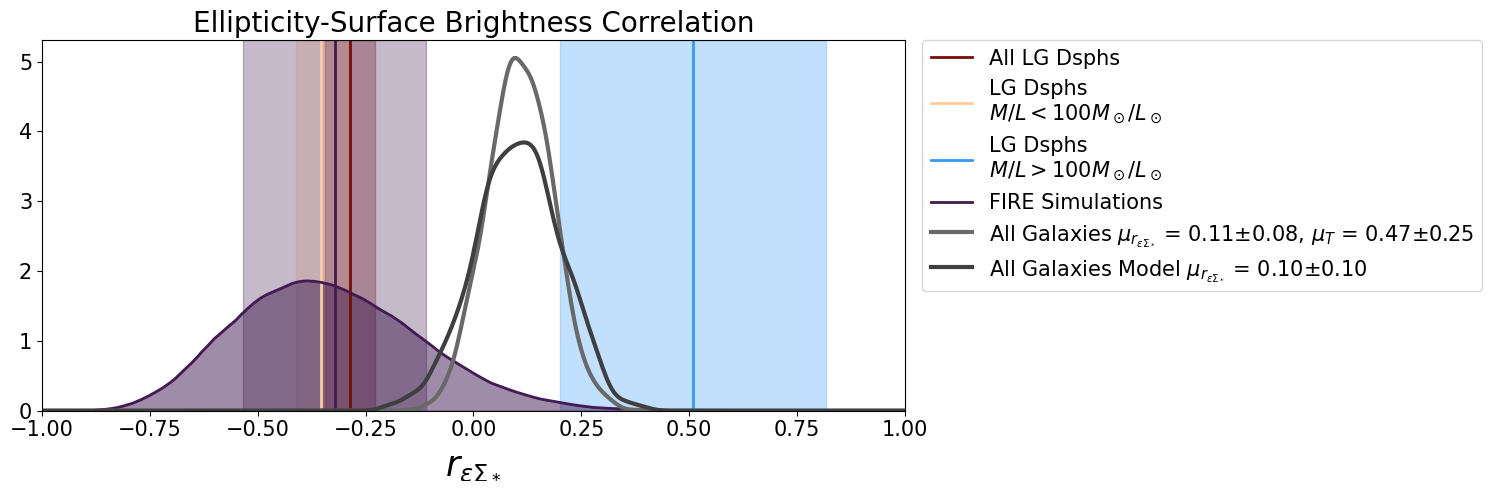

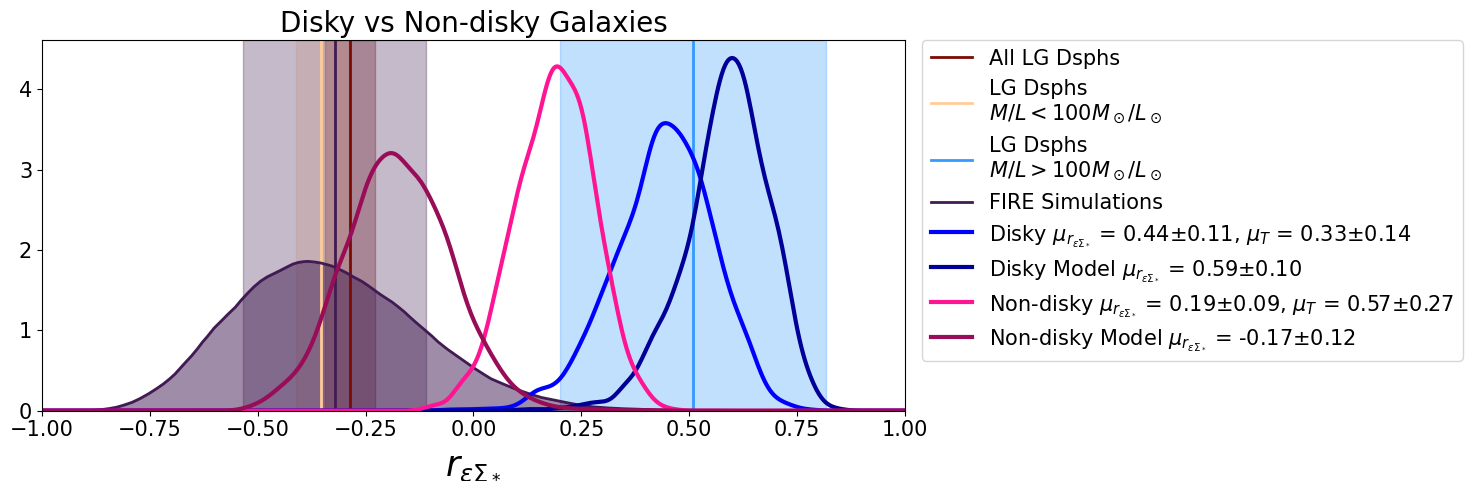

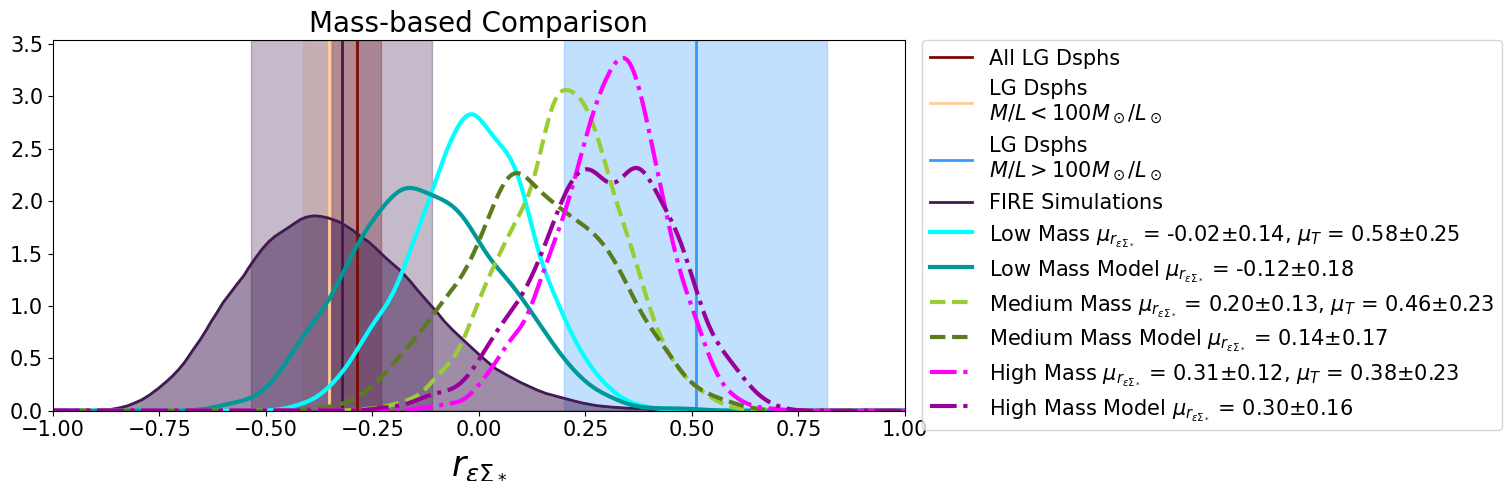

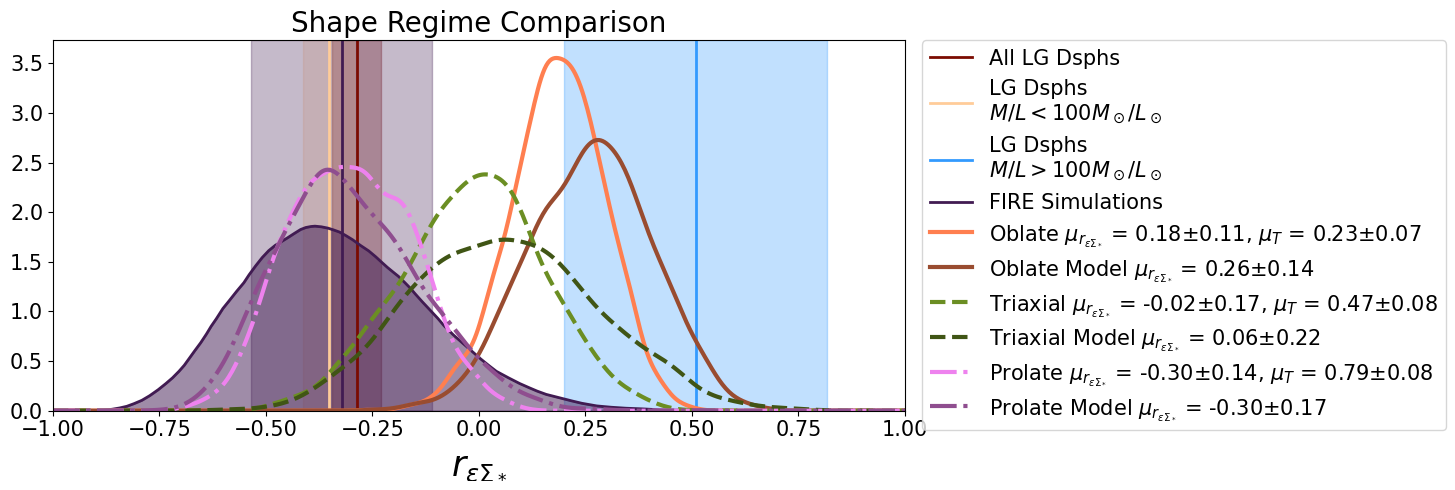

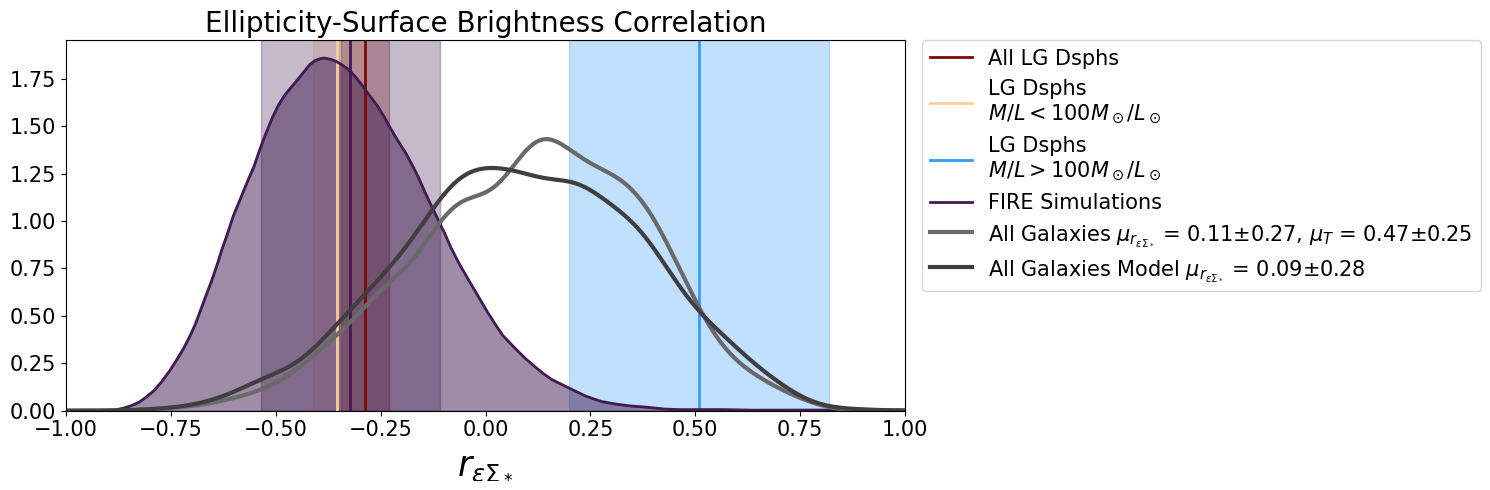

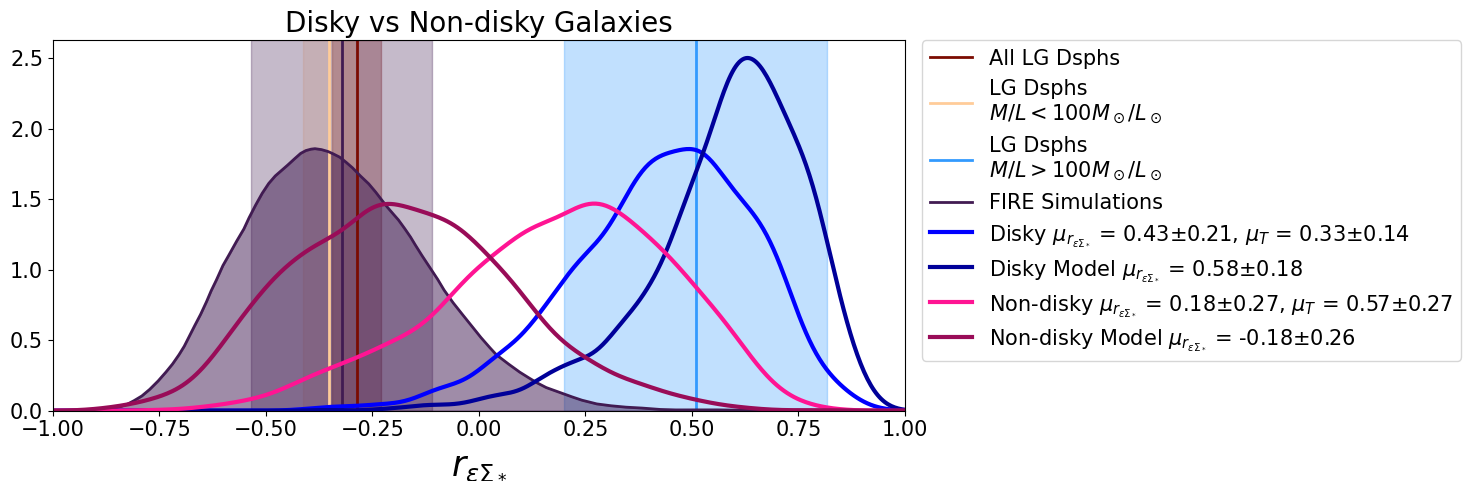

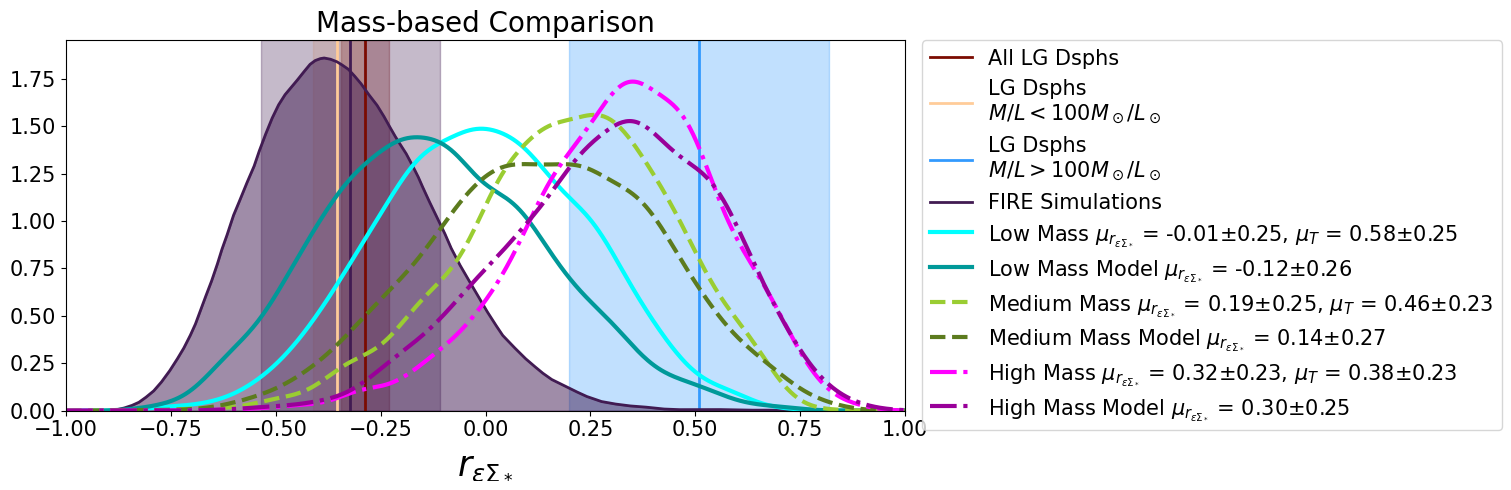

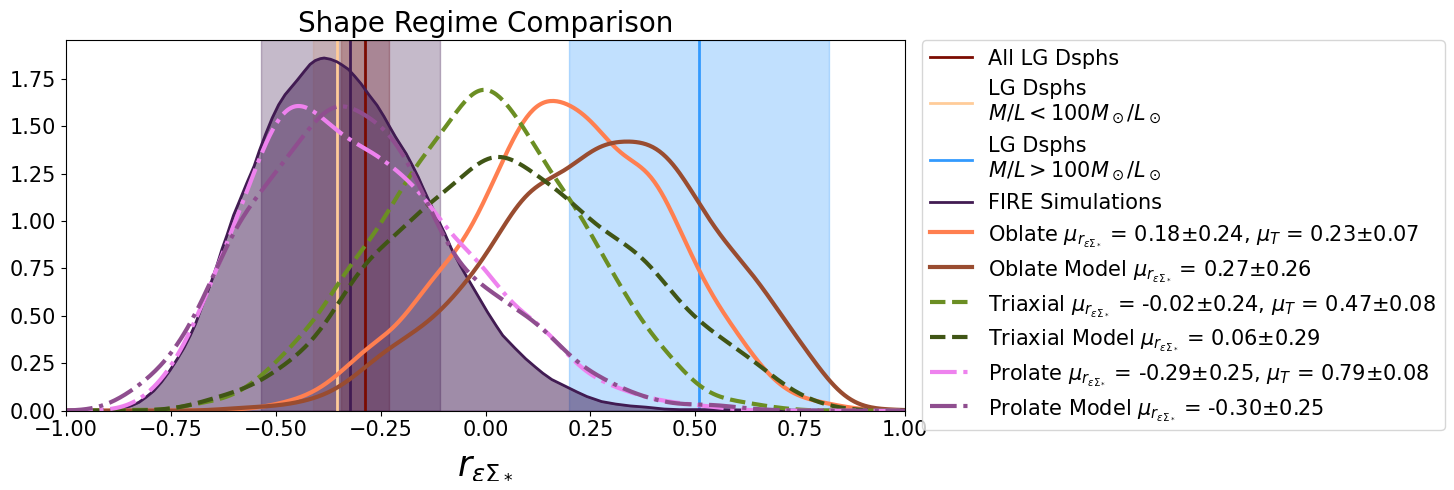

In [15]:

correlation_distributions_list = [correlation_distributions_all_galaxies_sampled,correlation_distributions_xu_sample_size]


for correlation_distributions in correlation_distributions_list:
    # 1. All galaxies (single category)
    plot_correlation_distribution(
        correlation_distributions,
        obs_data,
        fire_data,
        categories_to_plot=[
            {'key': 'all', 'label': 'All Galaxies', 'color': 'dimgray', 'linewidth': 3}
        ],
        title="Ellipticity-Surface Brightness Correlation",
        output_file=os.path.join(OUTPUT_DIR, 'Correlation_All.png')
    )


    # # 2. Central vs Satellite comparison
    # plot_correlation_distribution(
    #     correlation_distributions,
    #     obs_data,
    #     fire_data,
    #     categories_to_plot=[
    #         {'key': 'central', 'label': 'Centrals', 'color': 'blue', 'linestyle': '-'},
    #         {'key': 'satellite', 'label': 'Satellites', 'color': 'red', 'linestyle': '--'}
    #     ],
    #     title="Central vs Satellite Galaxies",
    #     output_file=os.path.join(OUTPUT_DIR, 'Correlation_Environment.png')
    # )

    # # 3. Bright vs Dim comparison
    # plot_correlation_distribution(
    #     correlation_distributions,
    #     obs_data,
    #     fire_data,
    #     categories_to_plot=[
    #         {'key': 'bright', 'label': r'$M/L<100M_\odot/L_\odot$', 'color': 'goldenrod', 'linestyle': '-'},
    #         {'key': 'dim', 'label': r'$M/L>100M_\odot/L_\odot$', 'color': 'navy', 'linestyle': '--'}
    #     ],
    #     title="Bright vs Dim Galaxies",
    #     output_file=os.path.join(OUTPUT_DIR, 'Correlation_MassToLight.png')
    # )

    # 4. Disky vs Non-disky comparison
    plot_correlation_distribution(
        correlation_distributions,
        obs_data,
        fire_data,
        categories_to_plot=[
            {'key': 'disky', 'label': 'Disky', 'color': 'blue', 'linestyle': '-'},
            {'key': 'non_disky', 'label': 'Non-disky', 'color': 'deeppink', 'linestyle': '-'}
        ],
        title="Disky vs Non-disky Galaxies",
        output_file=os.path.join(OUTPUT_DIR, 'Correlation_Shape.png')
    )

    # 5. Mass-based comparison
    plot_correlation_distribution(
        correlation_distributions,
        obs_data,
        fire_data,
        categories_to_plot=[
            {'key': 'low_mass', 'label': 'Low Mass', 'color': 'cyan', 'linestyle': '-'},
            {'key': 'medium_mass', 'label': 'Medium Mass', 'color': 'yellowgreen', 'linestyle': '--'},
            {'key': 'high_mass', 'label': 'High Mass', 'color': 'magenta', 'linestyle': '-.'}
        ],
        title="Mass-based Comparison",
        output_file=os.path.join(OUTPUT_DIR, 'Correlation_Mass.png')
    )


    # 6. plot oblate/triaxial/prolate comparison
    plot_correlation_distribution(
        correlation_distributions,
        obs_data,
        fire_data,
        categories_to_plot=[
            {'key': 'oblate', 'label': 'Oblate', 'color': 'coral', 'linestyle': '-'},
            {'key': 'triaxial', 'label': 'Triaxial', 'color': 'olivedrab', 'linestyle': '--'},
            {'key': 'prolate', 'label': 'Prolate', 'color': 'violet', 'linestyle': '-.'}
        ],
        title="Shape Regime Comparison",
        output_file=os.path.join(OUTPUT_DIR, 'Correlation_ShapeRegime.png')
    )

    # # Plot bar status comparison
    # plot_correlation_distribution(
    #     correlation_distributions,
    #     obs_data,
    #     fire_data,
    #     categories_to_plot=[
    #         {'key': 'barred', 'label': 'Barred', 'color': 'red', 'linestyle': '-'},
    #         {'key': 'non_barred', 'label': 'Non-barred', 'color': 'blue', 'linestyle': '--'},
    #         {'key': 'bar_unknown', 'label': 'Bar Status Unknown', 'color': 'gray', 'linestyle': ':'}
    #     ],
    #     title="Bar Status Comparison",
    #     output_file=os.path.join(OUTPUT_DIR, 'Correlation_BarStatus.png')
    # )


In [197]:

print(np.mean(correlation_distributions_all_galaxies_sampled['all']))
print(np.mean(correlation_distributions_all_galaxies_sampled['all_model_ideal']))
print(np.mean(correlation_distributions_all_galaxies_sampled['all_model_scatter']))

0.10830058906652208
0.16658725746641245
0.10949384295072391


In [ ]:
# Plot correlation results for individual galaxies
# Calculate individual galaxy correlations
print("\n" + "="*60)
print("Calculating individual galaxy correlations...")
print("="*60)
individual_results = calculate_individual_correlations(galaxy_list)


# Print summary statistics
print("\n" + "="*60)
print("Summary Statistics")
print("="*60)
for subset, dist in correlation_distributions.items():
    if subset == 'triaxiality_values':
        continue
    finite_values = dist[np.isfinite(dist)]
    if len(finite_values) > 0:
        mean_corr = np.mean(finite_values)
        std_corr = np.std(finite_values)
        print(f"{subset:12s}: r = {mean_corr:6.3f} ± {std_corr:5.3f}")


print("\nAnalysis complete!")




In [ ]:

# ===========================
# For correlation vs mass plots
# ===========================
import matplotlib.gridspec as gridspec
def plot_correlation_vs_mass(individual_results: Dict[str, List[float]],
                           categories_to_plot: List[Dict[str, any]],
                           output_file: str):
    """
    Plot correlation vs stellar mass for multiple categories.

    Parameters:
    -----------
    individual_results : dict
        Dictionary with correlation and property data
    categories_to_plot : list of dicts
        Each dict should have:
        - 'mask': boolean array or callable that returns boolean array
        - 'label': label for legend
        - 'color': color for plotting
        - 'marker': marker style (default: 'o')
        - 'size': marker size (default: 50)
    output_file : str
        Output file path
    """

    # Create figure with custom gridspec for different subplot sizes
    fig = plt.figure(figsize=(16, 4))
    gs = gridspec.GridSpec(1, 3, width_ratios=[2, 1, 0.1], hspace=0, wspace=0.1)

    # Create subplots
    ax1 = fig.add_subplot(gs[0, 0])  # Left plot (larger)
    ax2 = fig.add_subplot(gs[0, 1])  # Right plot (smaller, square)

    # Share y-axis between the two plots
    ax2.sharey(ax1)

    correlations = np.array(individual_results['correlations'])
    masses = np.array(individual_results['stellar_masses'])
    environments = individual_results['environments']

    # Left plot
    ax = ax1
    # Plot each category
    for category in categories_to_plot:
        # Get mask
        if callable(category['mask']):
            mask = category['mask'](individual_results)
        else:
            mask = category['mask']

        if np.sum(mask) > 0:
            ax.scatter(masses[mask], correlations[mask],
                      c=category['color'],
                      marker=category.get('marker', 'o'),
                      s=category.get('size', 50),
                      label=category['label'])

    # Add reference lines for shape regimes
    ax.axhline(-1/3, color='0.75', linestyle='--', zorder=0)
    ax.axhline(1/3, color='0.75', linestyle='--', zorder=0)

    # Labels
    ax.set_xlabel(r'Log(M$_*$/M$_\odot$)', fontsize=25)
    ax.set_ylabel(r'$r_{\epsilon\Sigma_*}$', fontsize=25)
    ax.set_xlim([5.8, 9.5])
    ax.set_ylim([-1, 1])
    ax.tick_params(which='both', labelsize=15)

    # Add shape regime labels
    ax.text(5.83, -0.66, 'Prolate', fontsize=18, rotation='vertical',
           verticalalignment='center', c='0.5')
    ax.text(5.83, 0, 'Triaxial', fontsize=18, rotation='vertical',
           verticalalignment='center', c='0.5')
    ax.text(5.83, 0.66, 'Oblate', fontsize=18, rotation='vertical',
           verticalalignment='center', c='0.5')

    ax.legend(loc='lower left', prop={'size': 18})

    # Right plot (smaller and square)
    triaxialities = np.array(individual_results['triaxialities'])
    ax2.scatter(triaxialities, correlations, s=50)

    # Set limits for the right plot
    ax2.set_xlim([0, 1])
    ax2.set_ylim([-1, 1])  # Explicitly set y-limits too

    # Make the right plot truly square
    # For x-range=1 and y-range=2, aspect ratio should be 0.5 for square appearance
    ax2.set_aspect(0.5, adjustable='box')

    ax2.tick_params(which='both', labelsize=15)
    ax2.set_xlabel('T', fontsize=20)

    # Remove y-axis labels from right plot since they're shared
    #ax2.set_yticklabels([])

    plt.tight_layout()
    plt.savefig(output_file, dpi=300)

# Define mask functions for complex selections
def is_bright_central(results):
    """Mask for bright central galaxies"""
    envs = np.array(results['environments'])
    masses = np.array(results['stellar_masses'])
    # Assuming you have mass_to_light in results, otherwise need to add it
    return (envs == 'central') & (masses > 7.0)  # Example condition

def is_dim_satellite(results):
    """Mask for dim satellite galaxies"""
    envs = np.array(results['environments'])
    masses = np.array(results['stellar_masses'])
    return (envs == 'satellite') & (masses < 7.0)

# 1. Simple environment comparison
plot_correlation_vs_mass(
    individual_results,
    categories_to_plot=[
        {'mask': np.array([env == 'central' for env in individual_results['environments']]),
         'label': 'Centrals', 'color': 'blue', 'marker': 'o'},
        {'mask': np.array([env == 'satellite' for env in individual_results['environments']]),
         'label': 'Satellites', 'color': 'red', 'marker': 'v'}
    ],
    output_file=os.path.join(OUTPUT_DIR, 'CorrVsMass_Environment.png')
)

# 2. Shape-based comparison
plot_correlation_vs_mass(
    individual_results,
    categories_to_plot=[
        {'mask': np.array(individual_results['triaxialities']) < 0.33,
         'label': 'Oblate', 'color': 'orange', 'marker': 's'},
        {'mask': np.array(individual_results['triaxialities']) > 0.67,
         'label': 'Prolate', 'color': 'purple', 'marker': '^'},
        {'mask': (np.array(individual_results['triaxialities']) >= 0.33) &
                 (np.array(individual_results['triaxialities']) <= 0.67),
         'label': 'Triaxial', 'color': 'green', 'marker': 'D'}
    ],
    output_file=os.path.join(OUTPUT_DIR, 'CorrVsMass_Shape.png')
)

# 3. Complex multi-category comparison
plot_correlation_vs_mass(
    individual_results,
    categories_to_plot=[
        {'mask': is_bright_central, 'label': 'Bright Centrals', 'color': 'darkblue', 'marker': 'o', 'size': 70},
        {'mask': is_dim_satellite, 'label': 'Dim Satellites', 'color': 'darkred', 'marker': 'v', 'size': 70},
        {'mask': np.array([env == 'unknown' for env in individual_results['environments']]),
         'label': 'Unclassified', 'color': 'gray', 'marker': 'x', 'size': 30}
    ],
    output_file=os.path.join(OUTPUT_DIR, 'CorrVsMass_Complex.png')
)

# disky vs non-disky comparison
def is_disky(results):
    """Mask for disky galaxies"""
    b_over_a = np.array(results['b_over_a'])
    c_over_a = np.array(results['c_over_a'])
    return (b_over_a > 0.65) & (c_over_a < 0.35)

disk_mask = is_disky(individual_results)
nondisk_mask = ~disk_mask
plot_correlation_vs_mass(
    individual_results,
    categories_to_plot=[
        {'mask': disk_mask , 'label': 'Disky', 'color': 'green', 'marker': 'o', 'size': 50},
        {'mask': nondisk_mask, 'label': 'Non-disky', 'color': 'purple', 'marker': 'o', 'size': 50}
    ],
    output_file=os.path.join(OUTPUT_DIR, 'CorrVsMass_Disky.png'))


In [ ]:



# 4. Custom color map based on continuous property
# This requires a slight modification to support colormaps
def plot_correlation_vs_mass_colormap(individual_results, color_property, output_file):
    """Special version that colors by a continuous property"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    #add a second box to the right side of the plot to plot t vs rcorr

    correlations = np.array(individual_results['correlations'])
    masses = np.array(individual_results['stellar_masses'])
    colors = np.array(individual_results[color_property])

    # Create scatter plot with colormap
    scatter = ax.scatter(masses, correlations, c=colors, cmap='viridis', s=50)

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(color_property.replace('_', ' ').title(), fontsize=15)

    # Rest of the plot setup...
    ax.axhline(-1/3, color='0.75', linestyle='--', zorder=0)
    ax.axhline(1/3, color='0.75', linestyle='--', zorder=0)
    ax.set_xlabel(r'Log(M$_*$/M$_\odot$)', fontsize=25)
    ax.set_ylabel(r'$r_{\epsilon\Sigma_*}$', fontsize=25)
    ax.set_xlim([5.8, 9.5])
    ax.set_ylim([-1, 1])

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

# Use it:
plot_correlation_vs_mass_colormap(
    individual_results,
    'triaxialities',
    os.path.join(OUTPUT_DIR, 'CorrVsMass_Triaxiality.png')
)

In [ ]:
correlation_distributions_all_galaxies_sampled = calculate_correlation_distributions(
    oblate_galaxy_list, n_iterations=500
)

In [ ]:
correlation_distributions_all_galaxies_sampled = calculate_correlation_distributions(
    prolate_galaxy_list, n_iterations=500
)

In [ ]:
correlation_distributions_all_galaxies_sampled = calculate_correlation_distributions(
    triaxial_galaxy_list, n_iterations=500
)